In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_ollama import ChatOllama
from langgraph.graph.message import add_messages
from dotenv import load_dotenv

from langgraph.prebuilt import ToolNode, tools_condition
from langchain_community.tools import (
    DuckDuckGoSearchRun,
    YahooFinanceNewsTool,
    PubmedQueryRun
)
from langchain_community.utilities import (
    DuckDuckGoSearchAPIWrapper,
    PubMedAPIWrapper
)
from langchain_core.tools import tool

import requests
import os
from datetime import datetime, date
from langchain_core.messages import ToolMessage

C:\Users\HP\AppData\Local\Temp\ipykernel_3420\3115916262.py:9: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import (
USER_AGENT environment variable not set, consider setting it to identify your requests.


In [2]:
from langchain_google_genai import ChatGoogleGenerativeAI

In [80]:
load_dotenv(override=True)

True

In [91]:
llm = ChatGoogleGenerativeAI(
    model="gemini-3.6-flash",
    thinking_level="low"
)

In [5]:
# Buit in Tools

# DuckDuckGo Search
search_tool = DuckDuckGoSearchRun(
    api_wrapper=DuckDuckGoSearchAPIWrapper(
        region="wt-wt",
        max_results=3
    )
)

# Yahoo Finance
finance_tool = YahooFinanceNewsTool()




# PubMed
pubmed_tool = PubmedQueryRun(
    api_wrapper=PubMedAPIWrapper(
        top_k_results=1,
        doc_content_chars_max=1200
    )
)

In [6]:
@tool
def calculate_age(birth_date: str) -> dict:
    """
    Calculate age from a birth date.
    Birth date format: YYYY-MM-DD
    """
    try:
        birth = datetime.strptime(birth_date, "%Y-%m-%d").date()
        today = date.today()

        if birth > today:
            return {"error": "Birth date cannot be in the future"}

        age = today.year - birth.year

        if (today.month, today.day) < (birth.month, birth.day):
            age -= 1

        return {
            "birth_date": birth_date,
            "current_date": str(today),
            "age": age
        }

    except ValueError:
        return {"error": "Invalid date format. Use YYYY-MM-DD"}

    except Exception as e:
        return {"error": str(e)}

In [7]:
@tool
def get_weather(city: str) -> dict:
    """
    Get the current weather for a city.

    Example cities:
    Dhaka
    London
    New York
    Tokyo

    Use this tool whenever the user asks about
    current weather, temperature, humidity,
    feels-like temperature, or wind speed.
    """

    try:

        # ----------------------------
        # Step 1: Find city coordinates
        # ----------------------------

        geo_url = (
            "https://geocoding-api.open-meteo.com/v1/search"
        )

        geo_response = requests.get(
            geo_url,
            params={
                "name": city,
                "count": 1,
                "language": "en"
            },
            timeout=10
        )

        geo_data = geo_response.json()

        if not geo_data.get("results"):

            return {
                "error": f"City '{city}' not found."
            }

        location = geo_data["results"][0]

        latitude = location["latitude"]
        longitude = location["longitude"]


        # ----------------------------
        # Step 2: Get current weather
        # ----------------------------

        weather_url = (
            "https://api.open-meteo.com/v1/forecast"
        )

        weather_response = requests.get(
            weather_url,
            params={
                "latitude": latitude,
                "longitude": longitude,
                "current": (
                    "temperature_2m,"
                    "apparent_temperature,"
                    "relative_humidity_2m,"
                    "wind_speed_10m"
                )
            },
            timeout=10
        )

        weather_data = weather_response.json()

        current = weather_data["current"]

        return {

            "city": location["name"],

            "country": location.get(
                "country",
                ""
            ),

            "temperature_c":
                current["temperature_2m"],

            "feels_like_c":
                current["apparent_temperature"],

            "humidity_percent":
                current["relative_humidity_2m"],

            "wind_speed_kmh":
                current["wind_speed_10m"]
        }


    except Exception as e:

        return {
            "error": str(e)
        }

In [8]:
print(
    calculate_age.invoke(
        {
            "birth_date": "2001-04-14"
        }
    )
)

{'birth_date': '2001-04-14', 'current_date': '2026-09-17', 'age': 25}


In [9]:
print(
    get_weather.invoke(
        {
            "city": "Beijing"
        }
    )
)

{'city': 'Beijing', 'country': 'China', 'temperature_c': 23.2, 'feels_like_c': 25.9, 'humidity_percent': 73, 'wind_speed_kmh': 1.8}


In [10]:
print(
    search_tool.invoke(
        "latest artificial intelligence news"
    )
)

6 hours ago - AI News delivers the latest updates in artificial intelligence, machine learning, deep learning, enterprise AI, and emerging tech worldwide. 5 hours ago - Explore the latest artificial intelligence news with Reuters - from AI breakthroughs and technology trends to regulation, ethics, business and global impact. 3 hours ago - News coverage on artificial intelligence and machine learning tech, the companies building them, and the ethical issues AI raises today.


In [11]:
print(
    pubmed_tool.invoke(
        "Alzheimer disease MRI"
    )
)

PMID: 42747246
Published: 2026-09-16
Title: Alzheimer's Co-Pathology Burden on Basal Forebrain Atrophy and Cognitive Impairment in Dementia with Lewy Bodies: A Cross-Sectional Pilot Study.
Copyright Information: © 2026 American Neurological Association.
Summary::
OBJECTIVE: Dementia with Lewy Bodies (DLB) is the second most common neurodegenerative dementia after Alzheimer's disease (AD), with significant pathological overlap between the two conditions. However, the impact of Alzheimer's co-pathology on basal forebrain (BF) atrophy and its relationship with neurodegeneration and cognitive decline in patients with DLB remains underexplored.
METHODS: Forty patients with DLB and 14 healthy controls (HCs) were included from the Centre for Neurodegenerative Diseases, University of Bari. Participants underwent neuropsychological evaluations, 3T magnetic resonance imaging (MRI) scans, and Alzheimer's biomarkers assessment. Patients with DLB were grouped by AD co-pathology using in vivo biomar

In [12]:
result = finance_tool.invoke("AAPL")

In [13]:
result

"What Happens To Apple Stock If Its Margin Keeps Slipping? | Trefis\nApple (AAPL) reported a record June quarter, with revenue up 16%. The stock has returned 42% over the past year against 17% for the S&P 500. That is a price built on everything going right, and by Apple's own guide the margin behind it is already giving way."

In [92]:

tools = [
    search_tool,
    finance_tool,
    pubmed_tool,
    calculate_age,
    get_weather
]


llm_with_tools = llm.bind_tools(tools)

In [15]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [16]:
def chat_node(state: ChatState):
    """LLM node that may answer or request a tool call."""
    messages = state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}


tool_node = ToolNode(tools)  

In [17]:
graph = StateGraph(ChatState)

graph.add_node("chat_node", chat_node)
graph.add_node("tools", tool_node)

In [18]:
graph.add_edge(START, "chat_node")

# If the LLM asked for a tool, go to ToolNode; else finish
graph.add_conditional_edges(
    "chat_node",
    tools_condition
)

graph.add_edge(
    "tools",
    "chat_node"
)

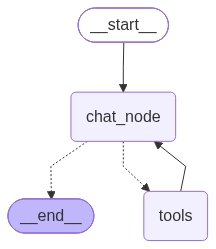

In [93]:
chatbot = graph.compile()

chatbot

In [20]:
def check_tool_usage(out):

    tool_used = False

    for message in out["messages"]:

        if hasattr(message, "tool_calls") and message.tool_calls:

            tool_used = True

            for tool_call in message.tool_calls:

                print("Tool used:", tool_call["name"])
                print("Arguments:", tool_call["args"])

    if not tool_used:

        print("No tool used - LLM answered by itself.")

In [23]:
out = chatbot.invoke({
    "messages": [
        HumanMessage(
            content="Hello my name is Farhan who are you and what can you do for me?"
        )
    ]
})

print(f"Tool usage: {check_tool_usage(out)}")
print(f"Final State: {out}")

print(f"Tool Response: {out['messages'][-2].content}")

print(f" AI Response: {out['messages'][-1].content}")



No tool used - LLM answered by itself.
Tool usage: None
Final State: {'messages': [HumanMessage(content='Hello my name is Farhan who are you and what can you do for me?', additional_kwargs={}, response_metadata={}, id='c346903a-a0e6-4afe-baf1-f572c29d69de'), AIMessage(content=[{'type': 'text', 'text': 'Hello Farhan! '}, {'type': 'text', 'text': '\n\nI am Gemini, a large language model built by Google. \n\nI am here to act as your virtual assistant, researcher, writer, and sounding board. Here is a quick overview of some of the things I can do for you:\n\n*   **Answer Questions & Explain Concepts:** I can explain complex topics, summarize long documents, or find information on history, science, pop culture, and more.\n*   **Search for Real-Time Information:** I can look up the latest news, weather, stock market updates, and biomedical research using specialized tools.\n*   **Write & Edit:** I can draft emails, write essays, generate creative stories, compose poetry, or help you polish y

In [24]:
out = chatbot.invoke({
    "messages": [
        HumanMessage(
            content="What is the weather in Dhaka?"
        )
    ]
})


print(f"Tool usage: {check_tool_usage(out)}")
print(f"Final State: {out}")

print(f"Tool Response: {out['messages'][-2].content}")

print(f" AI Response: {out['messages'][-1].content}")



Tool used: get_weather
Arguments: {'city': 'Dhaka'}
Tool usage: None
Final State: {'messages': [HumanMessage(content='What is the weather in Dhaka?', additional_kwargs={}, response_metadata={}, id='f0617480-c0e7-4950-bd18-91e500564b96'), AIMessage(content=[], additional_kwargs={'function_call': {'name': 'get_weather', 'arguments': '{"city": "Dhaka"}'}, '__gemini_function_call_thought_signatures__': {'call_13894': 'EsYBCsMBARFNMg/yewTw9AOsJSpKk/r0asW88ik6UreNZoQJ0YrehFl/Jvp2islkLKn4tWqHnZ+b0WgzbsJrFP/y/LwyzmpBU2C/JeIB+vno3rfR4CFJAcoAOJruVXKqR2KqmFcoFZuGsF1wGIxgkSfmuHa9hDGOtDbSs3j10qgy3OGxXv3phws4lYPiadsD5tT4zwfcYJiaZhhxL/lBTHtSOie9Ym2C60pCFCnO7xNN9QloNOc+YMaNK2o62q6X1NWwmL70DJit'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a0ab8a-a733-7c21-9e02-971d172a0651-0', tool_calls=[{'name': 'get_weather', 'args': {'city': 'Dhaka'}, 'id': 'call_13894', 'type': 'tool_call'}], invalid_tool_ca

In [37]:
out = chatbot.invoke({
    "messages": [
        HumanMessage(
            content="How old is someone born on 2000-05-20?"
        )
    ]
})

print(f"Tool usage: {check_tool_usage(out)}")
print(f"Final State: {out}")

print(f"Tool Response: {out['messages'][-2].content}")

print(f" AI Response: {out['messages'][-1].content}")

Tool used: calculate_age
Arguments: {'birth_date': '2000-05-20'}
Tool usage: None
Final State: {'messages': [HumanMessage(content='How old is someone born on 2000-05-20?', additional_kwargs={}, response_metadata={}, id='25ae344d-1ac7-433a-988d-1ebf9f326e92'), AIMessage(content=[], additional_kwargs={'function_call': {'name': 'calculate_age', 'arguments': '{"birth_date": "2000-05-20"}'}, '__gemini_function_call_thought_signatures__': {'call_63238': 'EssCCsgCARFNMg/2HziH30n8BZVuB/uqCE2E+r1ZdhHpylfwFihmfsVZV16Tzq/PvEOSfAVTibh/WtduPh2+HaDaLQ+fp+3Mlp6HTio5Hs30+J0aUyTOLNp5D6gBcsve4yl004ML4OROlwnElLJpmIG3uz5PGJ9ufiVk0Z0CiEogtFgBdj60R4Ax8I1h2okxAGH+Z8Q9XU6Sh9tuIeMqOt4r2ylkFZNVkaOU9YScwnFoI8ZsCPRQLBbe6LuvGMKqXotJQmkGxpxbz732o0sEhMrJOVeahra1uVGUckQWEk1IF9I020u0bXk9Gi87DP7I5VYc1hmGv75rQq+TusBSlgz8llXlifMUUvBS8utaA894GADF9DLj2vVP4pDEmrppZIuYm8mPhQM+1v682PkcMCR8GNcTJK8X5DZELUI7QTl9fM3J8qc6jDd4n6gQ6g=='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.6-flash', 'safety_ratings'

In [38]:
out = chatbot.invoke({
    "messages": [
        HumanMessage(
            content="give me latest financial news about Apple Inc (AAPL)"
        )
    ]
})

print(f"Tool usage: {check_tool_usage(out)}")
print(f"Final State: {out}")

print(f"Tool Response: {out['messages'][-2].content}")

print(f" AI Response: {out['messages'][-1].content}")

Tool used: yahoo_finance_news
Arguments: {'query': 'AAPL'}
Tool used: duckduckgo_search
Arguments: {'query': 'Apple AAPL stock financial news latest'}
Tool usage: None
Final State: {'messages': [HumanMessage(content='give me latest financial news about Apple Inc (AAPL)', additional_kwargs={}, response_metadata={}, id='65a965f1-32d2-416a-8f4c-9c3df28a79b7'), AIMessage(content=[], additional_kwargs={'function_call': {'name': 'yahoo_finance_news', 'arguments': '{"query": "AAPL"}'}, '__gemini_function_call_thought_signatures__': {'call_23756': 'EvEDCu4DARFNMg9Nh5op+4wd6Y9ILs9JWG4TxfrhpzvWWnUWMelJmRZU7Lb0cU++o5m6dOAmnxIahPLKhkTKoIdTqKEXRAhwA9OC1f5P+wGNjA8R3EZL/UMQPUotg03nQVYartPAJHCL37076Nrnaz18jf8DSzTZj5yHZzu0Dsez/Qovv/jOe/AmL7boIiX6EuR6oVhRb7vxQpyzGDs9arLA1MDXEKVw0LCG1TBB+NO0dbN9erGAAEa9ssmNO5Nn615JED72oibixUJhGb2OHQUZJXbrcP9X6WeiKFKfvPw776OmdowdGXt2LMu00rCgans/ucGb95zK5d04FKRH8FFevNo45grqJcPjskj1uEFPl+/9/FJni21L2M/9A4/1kdBgpnQCs63F/ab3+B/vjaaxpmOehO8DgdMzw6Q0DJ3ky+Dy4JPAGQKo3gIsMgA68XHwA

In [ ]:
out = chatbot.invoke({
    "messages": [
        HumanMessage(
            content="Tell me about latest research published on Cancer disease"
        )
    ]
})



print(f"Tool usage: {check_tool_usage(out)}")
print(f"Final State: {out}")
print(f"Tool Response: {out['messages'][-2].content}")
print(f" AI Response: {out['messages'][-1].content}")

Tool used: pub_med
Arguments: {'query': 'latest cancer research 2024'}
Tool used: pub_med
Arguments: {'query': 'cancer therapy breakthrough 2024'}
Tool used: duckduckgo_search
Arguments: {'query': 'latest cancer research breakthroughs 2024'}
Tool used: duckduckgo_search
Arguments: {'query': 'recent cancer research discoveries 2024 2025'}
Tool used: duckduckgo_search
Arguments: {'query': 'AACR 2024 annual meeting highlights cancer research'}
Tool used: duckduckgo_search
Arguments: {'query': 'cancer vaccine mRNA melanoma 2024 results'}
Tool used: duckduckgo_search
Arguments: {'query': 'liquid biopsy cancer FDA approval 2024'}
Tool used: duckduckgo_search
Arguments: {'query': 'Guardant Shield FDA approval 2024'}
Tool usage: None
Final State: {'messages': [HumanMessage(content='Tell me about latest research published on Cancer disease', additional_kwargs={}, response_metadata={}, id='b87543b2-ec49-457c-936f-845df70c120c'), AIMessage(content=[], additional_kwargs={'function_call': {'name': 

In [94]:
out = chatbot.invoke({
    "messages": [
        HumanMessage(
            content="What are the latest developments in quantum computing?"
        )
    ]
})

check_tool_usage(out)
print(f"Final State: {out}")
print(f"Tool Response: {out['messages'][-2].content}")
print(f" AI Response: {out['messages'][-1].content}")

Tool used: duckduckgo_search
Arguments: {'query': 'latest developments in quantum computing 2024 2025'}
Tool used: duckduckgo_search
Arguments: {'query': 'quantum computing major breakthroughs news 2024 2025 fault tolerant quantum computing error correction'}
Tool used: duckduckgo_search
Arguments: {'query': 'Google Willow quantum chip 2024 OR Quantinuum logical qubits OR Harvard QuEra logical qubits'}
Final State: {'messages': [HumanMessage(content='What are the latest developments in quantum computing?', additional_kwargs={}, response_metadata={}, id='ac58de46-92d0-4c2d-9b2b-2440b8b0793c'), AIMessage(content=[], additional_kwargs={'function_call': {'name': 'duckduckgo_search', 'arguments': '{"query": "latest developments in quantum computing 2024 2025"}'}, '__gemini_function_call_thought_signatures__': {'call_74605': 'Ep4CCpsCARFNMg9R2droIwJh1GhqTrGA9XYD1dwlDQ/J2ulrXabDiFo7eGZ3UTD3cBJADR6msjFyIIJY9UIlIlbm8wEYdhfZ5l7AHGR/CayuJ8jUpK8lVx4CrNv4TsLLnPMjLCxW4Q7vuObMZ+bYkcBcsaR8p09tI4c+5bDW

In [95]:
ai_response = out["messages"][-1].content[0]["text"]

print(ai_response)

Recent developments in quantum computing mark a fundamental shift from the **NISQ (Noisy Intermediate-Scale Quantum)** era toward **fault-tolerant, error-corrected quantum computing**. Rather than simply scaling up raw physical qubit counts, the focus has pivoted to improving gate fidelity, logical qubits, and error-correction protocols.

---

### 1. Breakthroughs in Quantum Error Correction & Logical Qubits
* **Google's Willow Processor:** Google unveiled its **105-qubit Willow chip**, demonstrating a critical threshold in quantum error correction: as the number of physical qubits used in an error-correcting surface code increases, the overall logical error rate decreases exponentially. Willow also achieved verifiable quantum advantage on benchmark tasks.
* **Microsoft & Quantinuum:** Microsoft and Quantinuum demonstrated reliable logical qubits by applying Microsoft's qubit-virtualization system to trapped-ion hardware, enabling active error detection and correction during computatio